> **Archived research notebook.** Retained for reproducibility and comparisons; it may require the historical code/dependencies. Use the [current notebook catalog](https://github.com/vtavakkoli/TinyCeNN-LM/blob/main/notebooks/README.md) for new runs.


# CeNNMixer-v4 — DeltaCell

CeNNMixer-v4 is a structural correction of v3.

v3 reached alpha=0.6 but generation collapsed even while mixer MSE kept improving.
The missing mechanisms are important parts of Qwen3.5 Gated DeltaNet itself.

v4 combines:

- compact CeNN fast / mid / slow cellular state
- causal depthwise convolution, kernel 4
- normalized q/k content addressing
- compact matrix fast-weight state
- per-token beta update strength
- per-token recurrent decay
- delta-rule correction
- gated RMS-normalized associative output
- top-1 margin distillation
- forward + reverse KL
- on-policy distillation on student-generated prefixes

Default compact associative state:

    8 heads × 32 key dim × 64 value dim

versus Qwen3.5 native linear-attention state:

    16 heads × 128 key dim × 128 value dim

The first target is still only layer 0.

**Run notes:** Quick mode is a diagnostic experiment, not a guarantee of full replacement.
A stopped quality gate is a result, not a runtime error. Upload is opt-in.
Full-model GPU convergence and speed must be measured in Colab.


In [1]:
#@title 1. Setup
import pathlib, subprocess, sys, importlib, json, torch, shutil

REPO_REF='fix/cennmixer-v4-runtime-training'
REPO_DIR=pathlib.Path('/content/TinyCeNN-LM-v4-fixed')
if not REPO_DIR.exists():
    subprocess.run(['git','clone','--branch',REPO_REF,
                    'https://github.com/vtavakkoli/TinyCeNN-LM.git',str(REPO_DIR)],check=True)
else:
    dirty=subprocess.check_output(['git','-C',str(REPO_DIR),'status','--porcelain'],text=True)
    if dirty.strip():
        raise RuntimeError('Checkout has local edits. Preserve them or choose another REPO_DIR.')
    subprocess.run(['git','-C',str(REPO_DIR),'fetch','origin',REPO_REF],check=True)
    subprocess.run(['git','-C',str(REPO_DIR),'checkout',REPO_REF],check=True)
    subprocess.run(['git','-C',str(REPO_DIR),'merge','--ff-only','FETCH_HEAD'],check=True)

subprocess.run([
    sys.executable,'-m','pip','install','-q','-U',
    'transformers==5.17.0','accelerate','datasets','pandas','matplotlib',
    'huggingface_hub','safetensors'
],check=True)
subprocess.run([sys.executable,'-m','pip','install','-q','-e',str(REPO_DIR)],check=True)

SRC=REPO_DIR/'src'
if str(SRC) not in sys.path:
    sys.path.insert(0,str(SRC))
for n in list(sys.modules):
    if n=='tinycenn_lm' or n.startswith('tinycenn_lm.'):
        del sys.modules[n]
importlib.invalidate_caches()

for p in [
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_cennmixer_v4_core.py',
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_cennmixer_v4.py',
    REPO_DIR/'src'/'tinycenn_lm'/'qwen35_cennmixer_v4_train.py',
    REPO_DIR/'scripts'/'run_qwen35_cennmixer_v4.py',
]:
    subprocess.run([sys.executable,'-m','py_compile',str(p)],check=True)

print('✓ CeNNMixer-v4 preflight OK')
print('CUDA:',torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:',torch.cuda.get_device_name(0))
else:
    raise RuntimeError('Select Runtime > Change runtime type > GPU, then rerun setup.')


✓ CeNNMixer-v4 preflight OK
CUDA: True
GPU: Tesla T4


In [2]:
#@title 2. Configuration
BASE_MODEL='Qwen/Qwen3.5-0.8B' #@param {type:'string'}
LAYERS='0' #@param {type:'string'}
QUICK_SMOKE=True #@param {type:'boolean'}
EXPLORE_HIGH_ALPHA=True #@param {type:'boolean'}
RESUME_ALPHA=-1.0 #@param {type:'number'}

# CeNN local branch
GROUPS=24 #@param {type:'integer'}
CELL_DIM=32 #@param {type:'integer'}
GRAPH_STEPS=1 #@param {type:'integer'}

# DeltaCell associative branch
ASSOC_HEADS=8 #@param {type:'integer'}
KEY_DIM=32 #@param {type:'integer'}
VALUE_DIM=64 #@param {type:'integer'}
CONV_KERNEL=4 #@param {type:'integer'}

LR=0.0002 #@param {type:'number'}
ON_POLICY_EVERY=40 #@param {type:'integer'}
ON_POLICY_TOKENS=12 #@param {type:'integer'}

# Full-run values. Quick mode overrides the data/training budget.
ALPHAS='0,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,1.0' #@param {type:'string'}
SEQ_LEN=128 #@param {type:'integer'}
TRAIN_BLOCKS=1536 #@param {type:'integer'}
VAL_BLOCKS=48 #@param {type:'integer'}
STAGE_UPDATES=300 #@param {type:'integer'}
EXTEND_UPDATES=200 #@param {type:'integer'}
MAX_STAGE_UPDATES=3000 #@param {type:'integer'}
PROBE_EVERY=50 #@param {type:'integer'}
PATIENCE_PROBES=8 #@param {type:'integer'}
MIN_LR=0.0000125 #@param {type:'number'}
TOPK=64 #@param {type:'integer'}

MIN_TOP1=0.97 #@param {type:'number'}
MAX_KL=0.03 #@param {type:'number'}
MAX_HIDDEN_MSE=0.05 #@param {type:'number'}
MAX_MIXER_MSE=0.12 #@param {type:'number'}

# Outside the checkout; set a mounted Drive path for persistence across runtime resets.
OUTPUT_DIR=pathlib.Path('/content/cennmixer_v4_results')

print('Quick smoke:',QUICK_SMOKE)
print('Explore higher alpha after soft misses:',EXPLORE_HIGH_ALPHA)
print('Resume alpha (-1 means fresh run):',RESUME_ALPHA)
print('CeNN local:',GROUPS,'×',CELL_DIM)
print('DeltaCell state:',ASSOC_HEADS,'×',KEY_DIM,'×',VALUE_DIM)
print('Runtime associative state floats:',ASSOC_HEADS*KEY_DIM*VALUE_DIM)


Quick smoke: True
Explore higher alpha after soft misses: True
Resume alpha (-1 means fresh run): -1.0
CeNN local: 24 × 32
DeltaCell state: 8 × 32 × 64
Runtime associative state floats: 16384


### Quick v4 test

Quick mode now uses finer steps once CeNN starts taking substantial control:

    0 → .10 → .20 → .30 → .40
      → .45 → .50 → .55 → .60 → .65
      → .70 → .75 → .80 → .85 → .90 → .95 → 1.0

With `EXPLORE_HIGH_ALPHA=True`, a stage may continue even if it narrowly misses
the normal smoke gate, provided the numerical model remains stable:

    violation <= 0.20
    top1 >= 0.82
    KL <= 0.20
    hidden MSE <= 0.18
    mixer MSE <= 0.30
    mixer cosine <= 0.15
    mixer delta <= 0.45

Generation Jaccard is still reported, but it is **not a hard continuation gate**
because five short prompts are too noisy to decide whether an architecture can
be explored at the next alpha.

On-policy distillation is again performed every 40 updates. A single on-policy
loss is dynamically capped in effective magnitude, so spikes from a poor sampled
prefix cannot dominate one optimizer step.

The strict scientific final gate is unchanged.


### Resume a saved stage

Set `RESUME_ALPHA` to the alpha of a best checkpoint in `OUTPUT_DIR`.
The runner loads that checkpoint and starts at the next configured alpha
(e.g. 0.45 after 0.4 in quick mode). Keep the same architecture and base model.
To retrain from scratch, use -1 and a new output directory.
Use a mounted Google Drive output path if checkpoints must survive a runtime reset.


In [3]:
#@title 3. Train CeNNMixer-v4
cmd=[
    sys.executable,'-u',str(REPO_DIR/'scripts'/'run_qwen35_cennmixer_v4.py'),
    '--base-model',BASE_MODEL,
    '--layers',LAYERS,
    '--alphas',ALPHAS,
    '--seq-len',str(SEQ_LEN),
    '--train-blocks',str(TRAIN_BLOCKS),
    '--val-blocks',str(VAL_BLOCKS),
    '--groups',str(GROUPS),
    '--cell-dim',str(CELL_DIM),
    '--graph-steps',str(GRAPH_STEPS),
    '--assoc-heads',str(ASSOC_HEADS),
    '--key-dim',str(KEY_DIM),
    '--value-dim',str(VALUE_DIM),
    '--conv-kernel',str(CONV_KERNEL),
    '--lr',str(LR),
    '--stage-updates',str(STAGE_UPDATES),
    '--extend-updates',str(EXTEND_UPDATES),
    '--max-stage-updates',str(MAX_STAGE_UPDATES),
    '--probe-every',str(PROBE_EVERY),
    '--patience-probes',str(PATIENCE_PROBES),
    '--min-lr',str(MIN_LR),
    '--topk',str(TOPK),
    '--on-policy-every',str(ON_POLICY_EVERY),
    '--on-policy-tokens',str(ON_POLICY_TOKENS),
    '--min-top1',str(MIN_TOP1),
    '--max-kl',str(MAX_KL),
    '--max-hidden-mse',str(MAX_HIDDEN_MSE),
    '--max-mixer-mse',str(MAX_MIXER_MSE),
    '--output-dir',str(OUTPUT_DIR),
]
if QUICK_SMOKE:
    cmd.append('--quick-smoke')
if EXPLORE_HIGH_ALPHA:
    cmd.append('--explore-high-alpha')
if RESUME_ALPHA >= 0:
    cmd += ['--resume-alpha',str(RESUME_ALPHA)]

print('='*120)
print(' '.join(cmd))
print('='*120)

p=subprocess.Popen(cmd,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True,bufsize=1)
for line in iter(p.stdout.readline,''):
    print(line,end='',flush=True)
rc=p.wait()
print('\nFinished, exit code',rc)
if rc:
    raise subprocess.CalledProcessError(rc,cmd)


/usr/bin/python3 -u /content/TinyCeNN-LM-v4-fixed/scripts/run_qwen35_cennmixer_v4.py --base-model Qwen/Qwen3.5-0.8B --layers 0 --alphas 0,0.05,0.10,0.20,0.30,0.40,0.50,0.60,0.70,0.80,0.90,1.0 --seq-len 128 --train-blocks 1536 --val-blocks 48 --groups 24 --cell-dim 32 --graph-steps 1 --assoc-heads 8 --key-dim 32 --value-dim 64 --conv-kernel 4 --lr 0.0002 --stage-updates 300 --extend-updates 200 --max-stage-updates 3000 --probe-every 50 --patience-probes 8 --min-lr 1.25e-05 --topk 64 --on-policy-every 40 --on-policy-tokens 12 --min-top1 0.97 --max-kl 0.03 --max-hidden-mse 0.05 --max-mixer-mse 0.12 --output-dir /content/cennmixer_v4_results --quick-smoke --explore-high-alpha
QUICK_SMOKE V4 {'alphas': '0,0.10,0.20,0.30,0.40,0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95,1.0', 'seq_len': 64, 'train_blocks': 384, 'val_blocks': 16, 'assoc': '8x32x64', 'conv_kernel': 4, 'on_policy_every': 40}
DEVICE cuda dtype torch.float16 layers [0] alphas [0.0, 0.1, 0.2, 0.3, 0.4, 0.45, 0.5, 0.55, 0

In [4]:
#@title 4. Results and parameter reduction
import pandas as pd
from IPython.display import display

report=json.loads((OUTPUT_DIR/'report.json').read_text())
stage=pd.read_csv(OUTPUT_DIR/'stage_summary.csv')
try:
    hist=pd.read_csv(OUTPUT_DIR/'training_history.csv')
except pd.errors.EmptyDataError:
    hist=pd.DataFrame()

print('Architecture:',report['architecture'])
print('Reached alpha:',report['reached_alpha'])
print('Progression complete:',report['progression_complete'])
print('Exploration mode:',report.get('exploration_mode'))
print('Exploration reached alpha:',report.get('exploration_reached_alpha'))
print('Strict final quality:',report['strict_quality_gate'])
print('CeNN-v4 params:',f"{report['cenn_params']:,}")
print('Qwen mixer params:',f"{report['replaced_qwen_mixer_params']:,}")
print('Mixer parameter reduction:',f"{report['mixer_param_reduction_pct']:.2f}%")

display(stage[[
    'alpha','best_step','trained_steps','pass','exploration_continue','violation',
    'student_ce','ce_gap','kl','reverse_kl','hidden_mse','delta_mse',
    'mixer_mse','mixer_cosine','mixer_delta','top1','top1_margin_loss',
    'generation_exact_rate','generation_mean_jaccard','generation_warning'
]])


Architecture: CeNNMixer-v4 DeltaCell: CeNN + compact gated-delta matrix memory
Reached alpha: 0.7
Progression complete: False
Exploration mode: True
Exploration reached alpha: 0.7
Strict final quality: False
CeNN-v4 params: 5,415,609
Qwen mixer params: 10,543,264
Mixer parameter reduction: 48.63%


,alpha,best_step,trained_steps,pass,exploration_continue,violation,student_ce,ce_gap,kl,reverse_kl,hidden_mse,delta_mse,mixer_mse,mixer_cosine,mixer_delta,top1,top1_margin_loss,generation_exact_rate,generation_mean_jaccard,generation_warning
0,0.00,280,280,True,False,0.000000,4.022228,0.000000,-4.862987e-09,0.000000,0.000000,0.000000,0.249323,0.128760,0.369053,1.000000,0.000967,1.0,1.000000,False
1,0.10,0,0,True,False,0.000000,4.014530,-0.007699,3.262063e-03,0.003255,0.004008,0.004912,0.249323,0.128760,0.369053,0.974609,0.025891,1.0,1.000000,False
2,0.20,0,0,True,False,0.000000,4.015356,-0.006873,1.416350e-02,0.014706,0.015981,0.019602,0.249323,0.128760,0.369053,0.948242,0.057312,0.4,0.818577,False
3,0.30,80,80,True,False,0.000000,4.020901,-0.001327,2.944558e-02,0.032922,0.032507,0.039810,0.239259,0.124228,0.351990,0.920898,0.093361,0.0,0.512733,False
4,0.40,240,240,False,True,0.042931,4.030124,0.007895,4.641599e-02,0.050346,0.050807,0.062808,0.214541,0.110483,0.319784,0.892578,0.128931,0.0,0.181201,False
5,0.45,140,240,False,True,0.027961,4.020248,-0.001980,7.228329e-02,0.075365,0.069866,0.086037,0.226483,0.117252,0.333919,0.882812,0.163645,0.0,0.181201,False
6,0.50,240,320,False,True,0.031250,4.036305,0.014077,7.242270e-02,0.074510,0.076776,0.095510,0.202627,0.103785,0.303917,0.871094,0.169790,0.0,0.278896,False
7,0.55,240,240,True,False,0.000000,4.068743,0.046514,8.374161e-02,0.092306,0.089210,0.111208,0.199169,0.102022,0.298570,0.865234,0.192764,0.0,0.262814,False
8,0.60,0,320,False,True,0.009779,4.090529,0.068301,1.074286e-01,0.123204,0.105964,0.132118,0.199169,0.102022,0.298570,0.851562,0.226971,0.0,0.187425,False
9,0.65,0,320,False,True,0.069274,4.114526,0.092298,1.340321e-01,0.151959,0.123858,0.154457,0.199169,0.102022,0.298570,0.831055,0.265442,0.0,0.143356,True


In [5]:
#@title 5. Compare directly with CeNNMixer-v3
V3_ALPHA06={
    'top1':0.84765625,
    'kl':0.1179187144,
    'hidden_mse':0.0986091695,
    'mixer_mse':0.1808171482,
    'generation_jaccard':0.1597098516,
}

print('v3 reference at alpha=0.6:',V3_ALPHA06)
for a in [0.5,0.6,0.7]:
    row=stage[(stage['alpha']-a).abs()<1e-9]
    if len(row):
        r=row.iloc[0]
        print(f"\nv4 alpha={a:g}")
        print(' top1:',float(r.top1))
        print(' KL:',float(r.kl))
        print(' hidden MSE:',float(r.hidden_mse))
        print(' mixer MSE:',float(r.mixer_mse))
        print(' generation Jaccard:',float(r.generation_mean_jaccard))

if len(stage[(stage['alpha']-0.6).abs()<1e-9]):
    r=stage[(stage['alpha']-0.6).abs()<1e-9].iloc[0]
    print('\nΔ v4-v3 at alpha=0.6:')
    print(' top1:',float(r.top1)-V3_ALPHA06['top1'])
    print(' generation Jaccard:',float(r.generation_mean_jaccard)-V3_ALPHA06['generation_jaccard'])


v3 reference at alpha=0.6: {'top1': 0.84765625, 'kl': 0.1179187144, 'hidden_mse': 0.0986091695, 'mixer_mse': 0.1808171482, 'generation_jaccard': 0.1597098516}

v4 alpha=0.5
 top1: 0.87109375
 KL: 0.0724227024475112
 hidden MSE: 0.0767762386240065
 mixer MSE: 0.2026267955079674
 generation Jaccard: 0.2788961038961038

v4 alpha=0.6
 top1: 0.8515625
 KL: 0.1074286303482949
 hidden MSE: 0.105963900219649
 mixer MSE: 0.1991692436859011
 generation Jaccard: 0.1874250749250749

v4 alpha=0.7
 top1: 0.818359375
 KL: 0.1599592980928719
 hidden MSE: 0.1432008468545973
 mixer MSE: 0.1991692436859011
 generation Jaccard: 0.255030895030895

Δ v4-v3 at alpha=0.6:
 top1: 0.00390625
 generation Jaccard: 0.027715223325074895


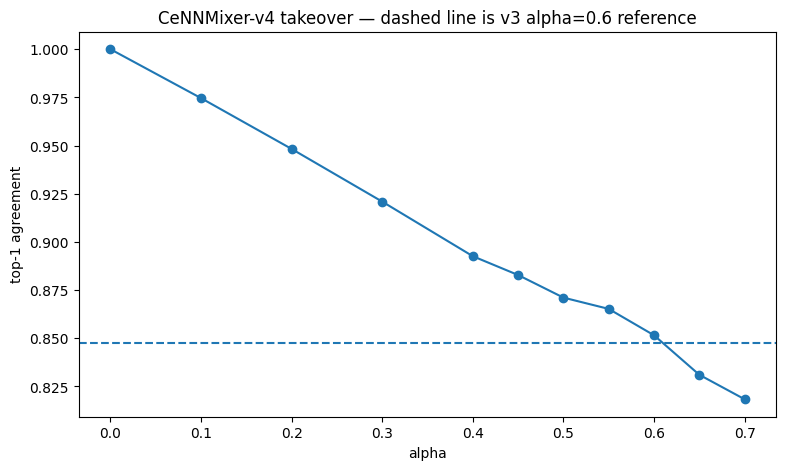

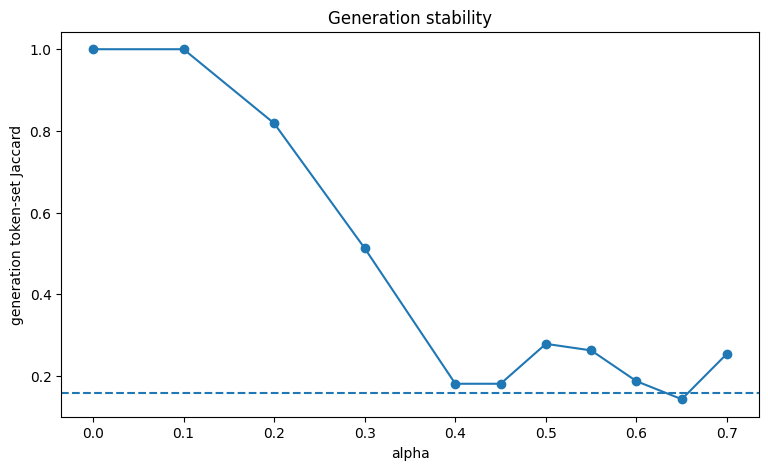

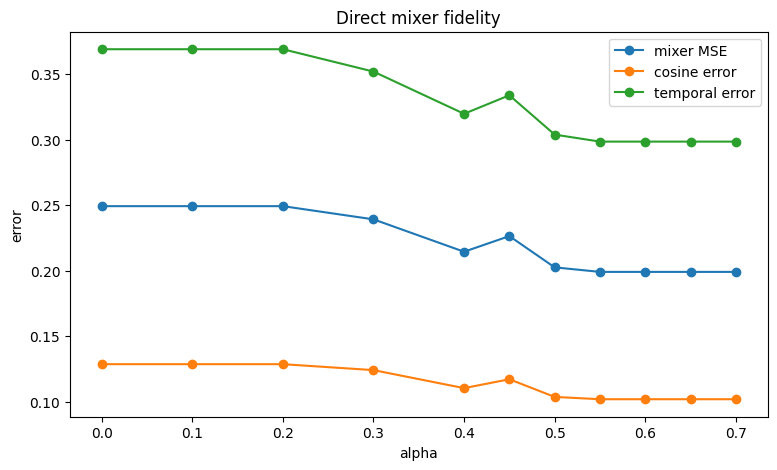

In [6]:
#@title 6. Curves
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))
plt.plot(stage['alpha'],stage['top1'],marker='o')
plt.axhline(V3_ALPHA06['top1'],linestyle='--')
plt.xlabel('alpha')
plt.ylabel('top-1 agreement')
plt.title('CeNNMixer-v4 takeover — dashed line is v3 alpha=0.6 reference')
plt.show()

plt.figure(figsize=(9,5))
plt.plot(stage['alpha'],stage['generation_mean_jaccard'],marker='o')
plt.axhline(V3_ALPHA06['generation_jaccard'],linestyle='--')
plt.xlabel('alpha')
plt.ylabel('generation token-set Jaccard')
plt.title('Generation stability')
plt.show()

plt.figure(figsize=(9,5))
plt.plot(stage['alpha'],stage['mixer_mse'],marker='o',label='mixer MSE')
plt.plot(stage['alpha'],stage['mixer_cosine'],marker='o',label='cosine error')
plt.plot(stage['alpha'],stage['mixer_delta'],marker='o',label='temporal error')
plt.xlabel('alpha')
plt.ylabel('error')
plt.legend()
plt.title('Direct mixer fidelity')
plt.show()


### Hard pass vs exploration continuation

- `pass=True`: the normal smoke-stage thresholds were satisfied.
- `exploration_continue=True`: the stage missed the normal threshold, but stayed coherent enough to continue testing larger alpha.
- Neither one changes the final scientific acceptance thresholds.
- Hugging Face upload remains blocked unless the final CeNN-only model passes the strict quality gate.


In [7]:
#@title 7. Final / latest generation samples
if report.get('progression_complete'):
    rows=report['final_cenn_only_generation']
    print('Final CeNN-only generation:')
else:
    last=float(stage.iloc[-1]['alpha'])
    path=OUTPUT_DIR/f"generation_alpha_{str(last).replace('.','p')}.json"
    rows=json.loads(path.read_text())
    print('Progression stopped at alpha',last,'— showing latest best generation.')

for i,x in enumerate(rows,1):
    print('\n'+'='*100)
    print(i,'USER:',x['prompt'])
    print('QWEN:',x['qwen'])
    print('CeNN-v4:',x['cenn'])
    print('exact=',x['exact'],'jaccard=',round(x['jaccard'],3))


Progression stopped at alpha 0.7 — showing latest best generation.

1 USER: What is 17 + 25? Give only the answer.
QWEN: 42
CeNN-v4: <think><think><think><think>
<think>

The answer is 42.
The answer is 42.
The answer is 42.
The answer is 42.
The
exact= False jaccard= 0.364

2 USER: Write one short sentence about Vienna.
QWEN: Vienna is a historic city known for its rich culture, vibrant nightlife, and stunning architecture.
CeNN-v4: <think>You are a human being.
You are a human being.
You are a human being.
You are a human being.
You are a human being.
You are a human being.
exact= False jaccard= 0.154

3 USER: Explain in one sentence what an API is.
QWEN: An API is a set of rules and protocols that allows software applications to communicate with each other.
CeNN-v4: <think>You are a good friend.
You are a good friend.
You are a good friend.
You are a good friend.
You are a good friend.
You are a good friend.
exact= False jaccard= 0.148

4 USER: Translate 'Good morning' into German. 

In [8]:
#@title 8. Inspect on-policy / margin training
if len(hist):
    cols=[
        'alpha','stage_step','train_forward_kl','train_reverse_kl',
        'train_rank_loss','train_margin_loss','train_on_policy_loss','train_on_policy_scale',
        'top1','top1_margin_loss'
    ]
    cols=[c for c in cols if c in hist.columns]
    display(hist[cols].tail(40))

    used=hist[hist['train_on_policy_loss']>0]
    print('On-policy updates recorded:',len(used))
    if len(used):
        display(used[cols].tail(20))


,alpha,stage_step,train_forward_kl,train_reverse_kl,train_rank_loss,train_margin_loss,train_on_policy_loss,train_on_policy_scale,top1,top1_margin_loss
87,0.60,220,0.100407,0.106592,0.096836,0.085742,0.000000,0.000000,0.842773,0.239120
88,0.60,240,0.066095,0.059323,0.088198,0.112842,0.106882,1.000000,0.835938,0.231708
89,0.60,260,0.072103,0.116561,0.059792,0.119189,0.000000,0.000000,0.844727,0.226707
90,0.60,280,0.041883,0.038999,0.070922,0.066943,0.105442,1.000000,0.833984,0.230669
91,0.60,300,0.042606,0.059087,0.050484,0.068164,0.000000,0.000000,0.833984,0.228291
92,0.60,320,0.024868,0.025928,0.035557,0.071436,0.056872,1.000000,0.843750,0.228630
93,0.65,1,0.199473,0.133000,0.170447,0.154297,0.000000,0.000000,0.819336,0.263332
94,0.65,20,0.112740,0.099322,0.170500,0.125391,0.000000,0.000000,0.796875,0.318166
95,0.65,40,0.063247,0.062396,0.084042,0.105273,0.141920,1.000000,0.816406,0.297182
96,0.65,60,0.052657,0.053658,0.073072,0.113574,0.000000,0.000000,0.802734,0.314658


On-policy updates recorded: 52


,alpha,stage_step,train_forward_kl,train_reverse_kl,train_rank_loss,train_margin_loss,train_on_policy_loss,train_on_policy_scale,top1,top1_margin_loss
86,0.60,200,0.129450,0.118241,0.150603,0.141406,0.174769,1.000000,0.833984,0.239641
88,0.60,240,0.066095,0.059323,0.088198,0.112842,0.106882,1.000000,0.835938,0.231708
90,0.60,280,0.041883,0.038999,0.070922,0.066943,0.105442,1.000000,0.833984,0.230669
92,0.60,320,0.024868,0.025928,0.035557,0.071436,0.056872,1.000000,0.843750,0.228630
95,0.65,40,0.063247,0.062396,0.084042,0.105273,0.141920,1.000000,0.816406,0.297182
97,0.65,80,0.081482,0.081040,0.090828,0.152271,0.062129,1.000000,0.809570,0.307672
99,0.65,120,0.209850,0.217175,0.205789,0.222217,0.039809,1.000000,0.813477,0.284976
101,0.65,160,0.089077,0.075447,0.087068,0.190137,0.051029,1.000000,0.812500,0.296231
103,0.65,200,0.170237,0.185743,0.186409,0.230249,0.192118,1.000000,0.817383,0.282134
105,0.65,240,0.100915,0.104231,0.175586,0.216406,0.058278,1.000000,0.808594,0.283885


In [9]:
#@title 9. Upload strict-quality final v4 model to Hugging Face
UPLOAD_TO_HF=False #@param {type:'boolean'}
if not UPLOAD_TO_HF:
    print('Upload skipped. Enable only after reviewing the strict final quality results.')
else:
    from huggingface_hub import HfApi, login
    import shutil, json

    if not report.get('progression_complete'):
        raise RuntimeError('CeNNMixer-v4 has not safely reached alpha=1; HF upload is blocked.')
    if not report.get('strict_quality_gate'):
        raise RuntimeError('CeNN-v4 reached alpha=1 but did not pass the strict quality gate; HF upload is blocked.')

    HF_REPO_ID='vtava/Qwen35-0.8B-CeNNMixer-v4-DeltaCell' #@param {type:'string'}
    HF_PRIVATE=False #@param {type:'boolean'}

    HF_EXPORT=REPO_DIR/'results'/'Qwen35-0.8B-CeNNMixer-v4-DeltaCell-HF'
    if HF_EXPORT.exists():
        shutil.rmtree(HF_EXPORT)
    HF_EXPORT.mkdir(parents=True,exist_ok=True)

    for name in ['cennmixer_v4_final_cenn_only.pt','report.json','stage_summary.csv','training_history.csv']:
        src=OUTPUT_DIR/name
        if src.exists():
            shutil.copy2(src,HF_EXPORT/name)

    (HF_EXPORT/'cennmixer_v4_config.json').write_text(json.dumps({
        'base_model':report['base_model'],
        'architecture':report['architecture'],
        'layers':report['layers'],
        'layer_kinds':report['layer_kinds'],
        'config':report['config'],
        'final_metrics':report['final_cenn_only_probe'],
    },indent=2),encoding='utf-8')

    m=report['final_cenn_only_probe']
    readme=f"""---
    base_model: {report['base_model']}
    library_name: transformers
    pipeline_tag: text-generation
    tags:
    - qwen
    - cenn
    - recurrent
    - delta-rule
    - fast-weight-memory
    - tinycenn
    ---

    # Qwen3.5-0.8B CeNNMixer-v4 DeltaCell

    CeNNMixer-v4 combines CeNN cellular recurrent state with a compact gated-delta
    matrix memory, causal depthwise convolution, gated RMS output, and on-policy
    distillation.

    Replaced layers: {report['layers']}

    Final CeNN-only metrics:
    - Top-1 agreement: {m['top1']:.6f}
    - KL: {m['kl']:.6f}
    - Hidden MSE: {m['hidden_mse']:.6f}
    - Student CE: {m['student_ce']:.6f}
    - Teacher CE: {m['teacher_ce']:.6f}

    Mixer parameter reduction: {report['mixer_param_reduction_pct']:.2f}%

    Project: https://github.com/vtavakkoli/TinyCeNN-LM
    """
    (HF_EXPORT/'README.md').write_text(readme,encoding='utf-8')

    token=None
    try:
        from google.colab import userdata
        token=userdata.get('HF_TOKEN')
    except Exception:
        pass
    if token:
        login(token=token,add_to_git_credential=False)
    else:
        login()

    api=HfApi()
    api.create_repo(HF_REPO_ID,repo_type='model',private=HF_PRIVATE,exist_ok=True)
    api.upload_folder(
        folder_path=str(HF_EXPORT),
        repo_id=HF_REPO_ID,
        repo_type='model',
        commit_message='Upload CeNNMixer-v4 DeltaCell final adapter and results',
    )
    print('✓ Uploaded: https://huggingface.co/'+HF_REPO_ID)


Upload skipped. Enable only after reviewing the strict final quality results.
